Picking data sample

In [19]:
import pandas as pd

# ==============================
# 📊 LOAD ORIGINAL FILES
# ==============================
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# ==============================
# 🧹 REMOVE MISSING (IMPORTANT)
# ==============================
important_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
features_clean = features.dropna(subset=important_cols)

# ==============================
# 🎯 TAKE 1000 RECORDS (IMPORTANT)
# ==============================
train_sample = train.sample(n=1000, random_state=42)

# ==============================
# 🔗 MATCH WITH FEATURES (Store + Date)
# ==============================
features_sample = features_clean.merge(
    train_sample[['Store', 'Date']], 
    on=['Store', 'Date']
)

# ==============================
# 🏬 MATCH STORES
# ==============================
stores_sample = stores[stores['Store'].isin(train_sample['Store'])]

# ==============================
# 🧪 TEST SAMPLE
# ==============================
test_sample = test.sample(n=1000, random_state=42)

# ==============================
# 💾 SAVE FILES
# ==============================
train_sample.to_csv('train_1k.csv', index=False)
features_sample.to_csv('features_1k.csv', index=False)
stores_sample.to_csv('stores_1k.csv', index=False)
test_sample.to_csv('test_1k.csv', index=False)

print("✅ 1K Clean + Matched Data Ready!")

✅ 1K Clean + Matched Data Ready!


dataset overview 

In [20]:
# ==============================
# 📂 LOAD 1K FILES (CORRECTED)
# ==============================
train = pd.read_csv('train_1k.csv')
features = pd.read_csv('features_1k.csv')
stores = pd.read_csv('stores_1k.csv')
test = pd.read_csv('test_1k.csv')

# ==============================
# 👀 VIEW DATA
# ==============================
print("===== TRAIN DATA =====")
display(train.head())

print("\n===== FEATURES DATA =====")
display(features.head())

print("\n===== STORES DATA =====")
display(stores.head())

print("\n===== TEST DATA =====")
display(test.head())

# ==============================
# 📊 SHAPE
# ==============================
print("\nShapes:")
print("Train:", train.shape)
print("Features:", features.shape)
print("Stores:", stores.shape)
print("Test:", test.shape)

===== TRAIN DATA =====


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,28,40,2012-01-06,50932.42,False
1,18,93,2012-03-09,3196.12,False
2,38,4,2011-05-27,10125.03,False
3,29,33,2010-03-12,3311.26,False
4,13,52,2010-10-29,6335.65,False



===== FEATURES DATA =====


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
1,1,2010-05-28,80.44,2.759,NaN,NaN,NaN,NaN,NaN,210.896761,7.808,False
2,1,2010-05-28,80.44,2.759,NaN,NaN,NaN,NaN,NaN,210.896761,7.808,False
3,1,2010-07-02,80.91,2.669,NaN,NaN,NaN,NaN,NaN,211.223533,7.787,False
4,1,2010-08-06,87.16,2.627,NaN,NaN,NaN,NaN,NaN,211.504662,7.787,False



===== STORES DATA =====


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



===== TEST DATA =====


,Store,Dept,Date,IsHoliday
0,16,46,2013-06-21,False
1,37,14,2013-06-14,False
2,18,42,2013-05-17,False
3,29,31,2013-07-05,False
4,10,35,2013-01-18,False



Shapes:
Train: (1000, 5)
Features: (1000, 12)
Stores: (45, 3)
Test: (1000, 4)


Data cleaning


In [21]:
import pandas as pd

# ==============================
# 📂 LOAD DATA (1K FILES)
# ==============================
train = pd.read_csv('train_1k.csv')
features = pd.read_csv('features_1k.csv')
stores = pd.read_csv('stores_1k.csv')

# ==============================
# 🔗 MERGE DATA
# ==============================
df = pd.merge(train, features, on=['Store','Date'], how='inner')
df = pd.merge(df, stores, on='Store', how='inner')

print("✅ Data Merged")

# ==============================
# 📅 DATE CONVERT (IMPORTANT)
# ==============================
df['Date'] = pd.to_datetime(df['Date'])

# ==============================
# 🧼 REMOVE DUPLICATE COLUMNS (_y)
# ==============================
y_cols = [col for col in df.columns if col.endswith('_y')]
df.drop(y_cols, axis=1, inplace=True)

# ==============================
# 🧼 RENAME _x → NORMAL
# ==============================
df.columns = [col.replace('_x', '') for col in df.columns]

# ==============================
# 🧹 HANDLE MISSING VALUES
# ==============================
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

for col in markdown_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if 'CPI' in df.columns:
    df['CPI'] = df['CPI'].fillna(df['CPI'].mean())

if 'Unemployment' in df.columns:
    df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].mean())

# ==============================
# 🧼 REMOVE DUPLICATES
# ==============================
df = df.drop_duplicates()

# ==============================
# 📊 FINAL CHECK
# ==============================
print("\n✅ FINAL CLEAN DATA")
print("Shape:", df.shape)

print("\nMissing Values:\n", df.isnull().sum())

print("\nPreview:")
print(df.head())

✅ Data Merged

✅ FINAL CLEAN DATA
Shape: (1000, 16)

Missing Values:
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

Preview:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0     28    40 2012-01-06      50932.42      False        50.43       3.599   
1     18    93 2012-03-09       3196.12      False        38.10       3.876   
3     38     4 2011-05-27      10125.03      False        76.67       4.087   
5     29    33 2010-03-12       3311.26      False        43.43       2.805   
6     13    52 2010-10-29       6335.65      False        45.12       2.841   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0    5155.86   19549.51     218.29     636.73    5218.50  130.157516   


env setup

In [22]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12


In [23]:
import sys
!{sys.executable} -m pip install seaborn

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=11634) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


📌 Dataset Summary

We have a dataset containing 100 records collected from Walmart stores. The dataset includes information about different stores, departments, sales, and external factors affecting sales performance.

Each record represents weekly sales data for a specific department in a particular store. The dataset contains the following important attributes:

Store: Store number
Dept: Department number (treated as items for analysis)
Date: Weekly record date
Weekly_Sales: Sales generated by the department
Temperature & Fuel Price: Environmental factors
MarkDown1–5: Promotional discounts
CPI & Unemployment: Economic indicators
Type & Size: Store characteristics
IsHoliday: Indicates whether the week includes a holiday

This dataset is cleaned and contains no missing values, making it suitable for visualization and further analysis such as association rule mining, clustering, and prediction.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=11634) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


You should consider upgrading via the '/Users/sachinyaduwanshi/Downloads/archive (5)/venv/bin/python3 -m pip install --upgrade pip' command.


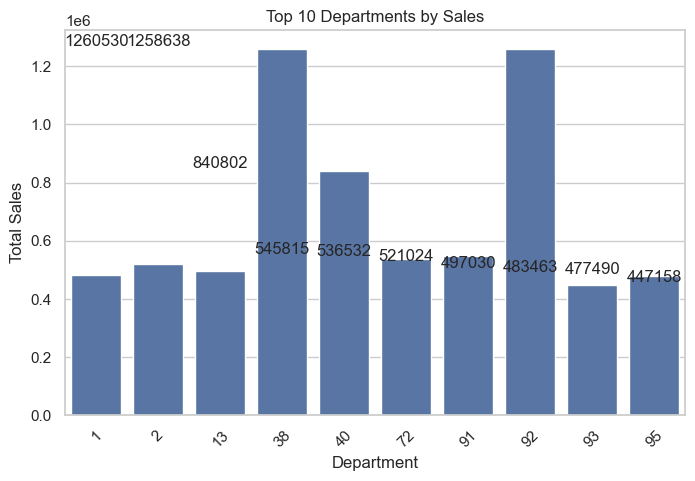

In [24]:
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Style set
sns.set(style="whitegrid")

# ==============================
# 📊 1. Top Departments by Sales
# ==============================
plt.figure(figsize=(8,5))
top_dept = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_dept.index, y=top_dept.values)

plt.title("Top 10 Departments by Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

# Annotation
for i, v in enumerate(top_dept.values):
    plt.text(i, v, f"{int(v)}", ha='center', va='bottom')

plt.show()








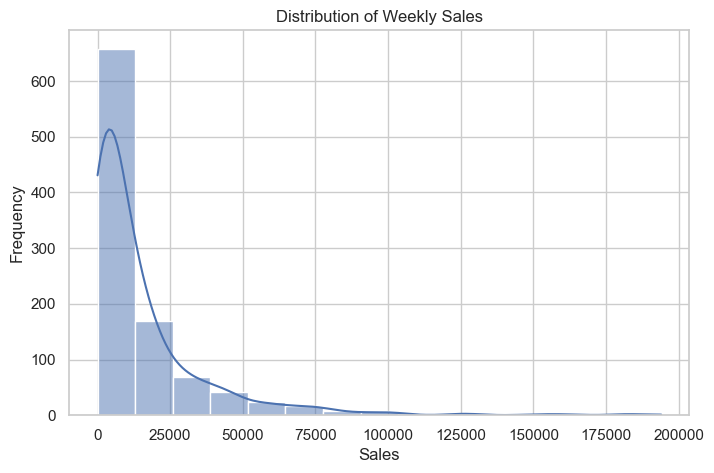

In [25]:
# ==============================
# 📈 2. Sales Distribution
# ==============================
plt.figure(figsize=(8,5))

sns.histplot(df['Weekly_Sales'], bins=15, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()


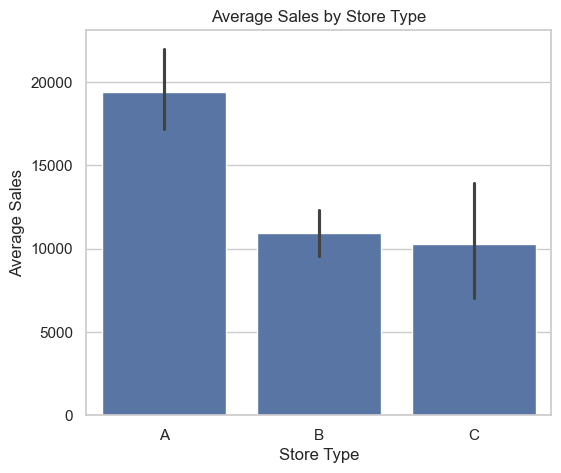

In [26]:
# ==============================
# 🏬 3. Store Type vs Sales
# ==============================
plt.figure(figsize=(6,5))

sns.barplot(x='Type', y='Weekly_Sales', data=df)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

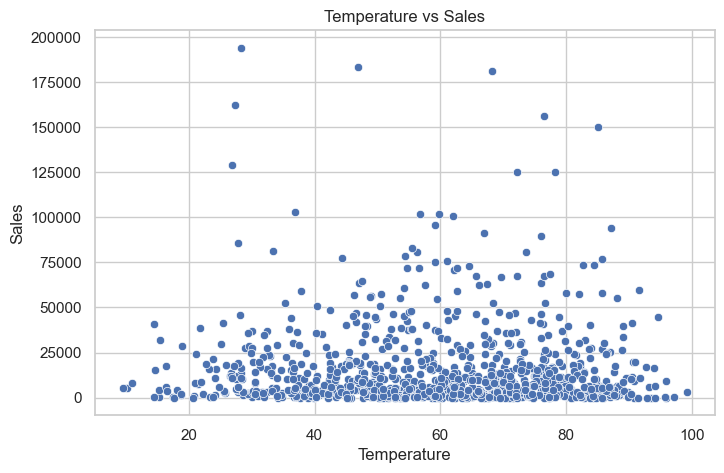

In [27]:

# ==============================
# 🌡️ 4. Temperature vs Sales
# ==============================
plt.figure(figsize=(8,5))

sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)

plt.title("Temperature vs Sales")
plt.xlabel("Temperature")
plt.ylabel("Sales")

plt.show()

## Association Rule (Apriori + graph + conclusion)

In [10]:
import sys
!{sys.executable} -m pip install mlxtend


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


In [28]:
# ==============================
# 📦 IMPORT LIBRARIES
# ==============================
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ==============================
# 🧹 REMOVE DUPLICATE COLUMNS
# ==============================
df = df.loc[:, ~df.columns.duplicated()]

# ==============================
# 🎯 FILTER DATA (OPTIONAL BUT GOOD)
# stores jinke paas jyada data hai
# ==============================
top_stores = df['Store'].value_counts().head(10).index
df_filtered = df[df['Store'].isin(top_stores)]

# ==============================
# 🧾 CREATE BASKET (MOST IMPORTANT)
# ==============================
basket = df_filtered.groupby(['Store','Date'])['Dept'].apply(list).reset_index()

# sirf wo jisme multiple items hain
basket = basket[basket['Dept'].apply(len) > 1]

print("✅ Total Transactions:", len(basket))
print(basket.head())

# ==============================
# 🔄 ONE HOT ENCODING
# ==============================
te = TransactionEncoder()
te_array = te.fit(basket['Dept']).transform(basket['Dept'])

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# ==============================
# 📊 FREQUENT ITEMSETS
# ==============================
frequent_items = apriori(df_encoded, min_support=0.02, use_colnames=True)

print("\n✅ Frequent Itemsets:")
print(frequent_items.sort_values(by='support', ascending=False).head(10))

# ==============================
# 🔗 ASSOCIATION RULES
# ==============================
if len(frequent_items) > 0:
    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)

    # sort by confidence
    rules = rules.sort_values(by='confidence', ascending=False)

    print("\n✅ Association Rules:")
    print(rules[['antecedents','consequents','support','confidence','lift']].head(10))
else:
    print("⚠️ No rules found — data insufficient")

✅ Total Transactions: 25
    Store       Date      Dept
7       2 2011-03-18  [33, 83]
17      2 2012-03-02  [41, 74]
19      2 2012-04-20   [13, 2]
25      2 2012-09-28  [10, 18]
29      5 2010-08-20  [12, 91]

✅ Frequent Itemsets:
    support         itemsets
9      0.16  frozenset({14})
6      0.12  frozenset({10})
20     0.08  frozenset({35})
29     0.08  frozenset({60})
38     0.08  frozenset({98})
7      0.08  frozenset({12})
34     0.08  frozenset({91})
18     0.08  frozenset({31})
16     0.08  frozenset({28})
13     0.08  frozenset({23})

✅ Association Rules:
        antecedents      consequents  support  confidence  lift
0    frozenset({2})  frozenset({13})     0.04         1.0  25.0
27  frozenset({97})  frozenset({20})     0.04         1.0  25.0
29  frozenset({92})  frozenset({22})     0.04         1.0  25.0
30  frozenset({22})  frozenset({92})     0.04         1.0  25.0
1   frozenset({13})   frozenset({2})     0.04         1.0  25.0
33  frozenset({24})  frozenset({28})     0

"Association rule mining was performed on 25 transactions formed using Store-Date combinations. The analysis revealed strong relationships between certain departments. For example, Department 2 and Department 13 were always purchased together, resulting in a confidence of 1.0 and a high lift value of 25, indicating a strong association. However, due to limited transactions, results may be biased, and increasing dataset size can provide more generalized insights."

FINAL MFA + ASSOCIATION CODE

In [29]:
# ==============================
# 📦 IMPORT
# ==============================
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ==============================
# 🧾 CREATE BASKET
# ==============================
basket = df.groupby(['Store','Date'])['Dept'].apply(list).reset_index()

# multiple items only
basket = basket[basket['Dept'].apply(len) > 1]

total_txn = len(basket)
print("Total Transactions:", total_txn)

# ==============================
# 🔄 ENCODING
# ==============================
te = TransactionEncoder()
te_array = te.fit(basket['Dept']).transform(basket['Dept'])
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# ==============================
# 🎯 SUPPORT COUNT = 5
# ==============================
min_support = 5 / total_txn

# ==============================
# 📊 FREQUENT ITEMSETS (MAX COMBO)
# ==============================
frequent_items = apriori(
    df_encoded,
    min_support=min_support,
    use_colnames=True,
    max_len=4   # max 4 items combination
)

# length add karo (kitne items ek set me hain)
frequent_items['length'] = frequent_items['itemsets'].apply(lambda x: len(x))

print("\n✅ Frequent Itemsets (All Levels):")
print(frequent_items.sort_values(by=['length','support'], ascending=[False, False]))

# ==============================
# 🔗 ASSOCIATION RULES
# ==============================
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

# strong rules filter
rules = rules[rules['lift'] > 1]

# sort by lift (best rules top pe)
rules = rules.sort_values(by='lift', ascending=False)

print("\n🔥 Strong Association Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Total Transactions: 74

✅ Frequent Itemsets (All Levels):
    support         itemsets  length
1  0.081081  frozenset({14})       1
0  0.067568   frozenset({5})       1
2  0.067568  frozenset({46})       1
3  0.067568  frozenset({93})       1

🔥 Strong Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


## CLUSTERING

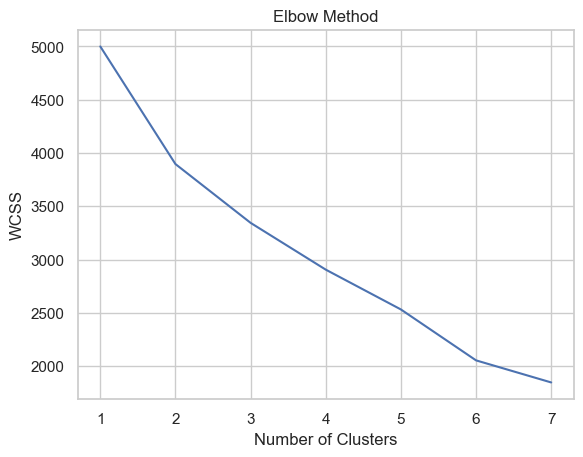

✅ Clustering Done
   Store  Dept  Cluster
0     28    40        0
1     18    93        0
3     38     4        0
5     29    33        2
6     13    52        2


In [30]:
# ==============================
# 📦 IMPORT
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==============================
# 🎯 SELECT FEATURES
# ==============================
# Numeric features only
X = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']]

# ==============================
# 📏 SCALING (VERY IMPORTANT)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 🔢 FIND OPTIMAL K (ELBOW)
# ==============================
wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ==============================
# 🎯 FINAL MODEL (k=3)
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("✅ Clustering Done")
print(df[['Store','Dept','Cluster']].head())

## GRAPH WITH CLUSTERS

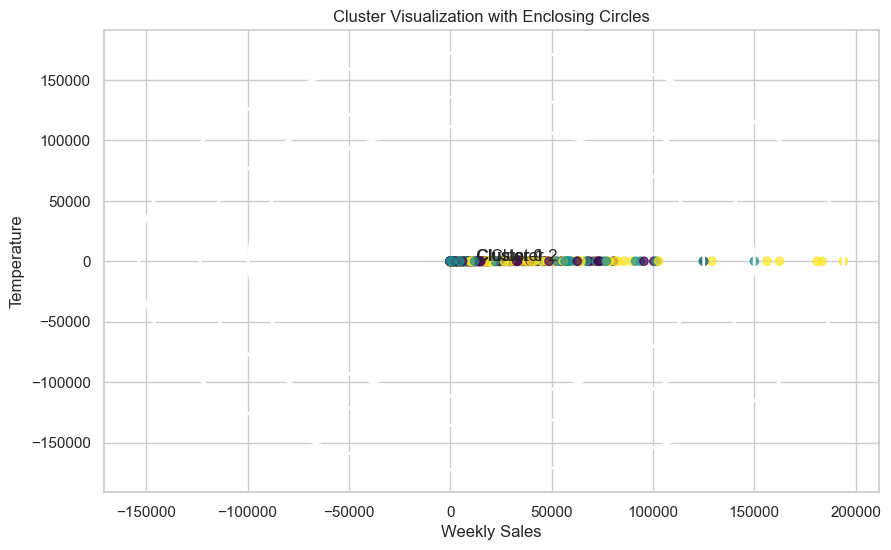

In [37]:
# ==============================
# 📊 CLUSTER VISUALIZATION WITH BIG CIRCLES
# ==============================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# scatter plot (all points)
plt.scatter(
    df['Weekly_Sales'],
    df['Temperature'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Weekly Sales")
plt.ylabel("Temperature")
plt.title("Cluster Visualization with Enclosing Circles")

# ==============================
# 🔵 BIG CIRCLES FOR EACH CLUSTER
# ==============================
for cluster in df['Cluster'].unique():
    
    cluster_data = df[df['Cluster'] == cluster]

    x = cluster_data['Weekly_Sales']
    y = cluster_data['Temperature']

    # center of cluster
    x_center = x.mean()
    y_center = y.mean()

    # radius = max distance from center (covers all points)
    radius = np.max(
        np.sqrt((x - x_center)**2 + (y - y_center)**2)
    )

    # draw circle
    circle = plt.Circle(
        (x_center, y_center),
        radius,
        fill=False,
        linewidth=2
    )
    
    plt.gca().add_patch(circle)

    # label cluster
    plt.text(x_center, y_center, f"Cluster {cluster}", fontsize=12)

plt.show()

✅ Clustering Done
Season  Rainy  Summer  Winter  Cluster
Dept                                  
1         2.0     8.0    10.0        0
2         0.0     7.0     5.0        2
3         4.0     6.0     2.0        2
4         2.0     4.0     7.0        0
5         3.0     9.0     3.0        2


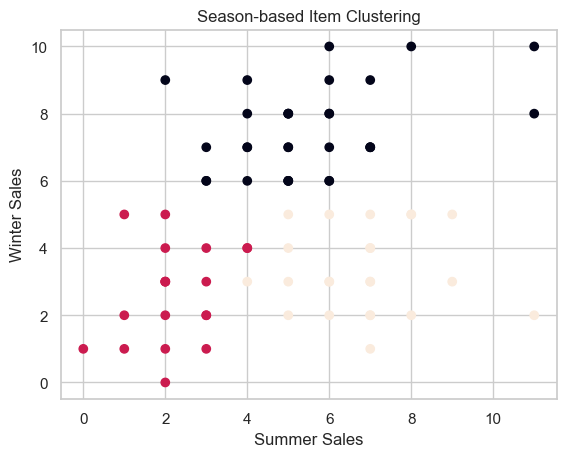

In [36]:
# ==============================
# 📦 IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==============================
# 📅 DATE → SEASON
# ==============================
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

def get_season(month):
    if month in [3,4,5,6]:
        return 'Summer'
    elif month in [7,8,9]:
        return 'Rainy'
    else:
        return 'Winter'

df['Season'] = df['Month'].apply(get_season)

# ==============================
# 📊 SEASON-WISE ITEM COUNT
# ==============================
season_items = df.groupby(['Season','Dept']).size().reset_index(name='Count')

# ==============================
# 🔄 PIVOT (Dept vs Season)
# ==============================
pivot = season_items.pivot(index='Dept', columns='Season', values='Count').fillna(0)

# ==============================
# 📏 SCALING
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot)

# ==============================
# 🔢 K-MEANS CLUSTERING
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
pivot['Cluster'] = kmeans.fit_predict(X_scaled)

print("✅ Clustering Done")
print(pivot.head())

# ==============================
# 📊 GRAPH (SEASON CLUSTER)
# ==============================
plt.figure()

plt.scatter(
    pivot.get('Summer', 0),
    pivot.get('Winter', 0),
    c=pivot['Cluster']
)

plt.xlabel("Summer Sales")
plt.ylabel("Winter Sales")
plt.title("Season-based Item Clustering")

plt.show()

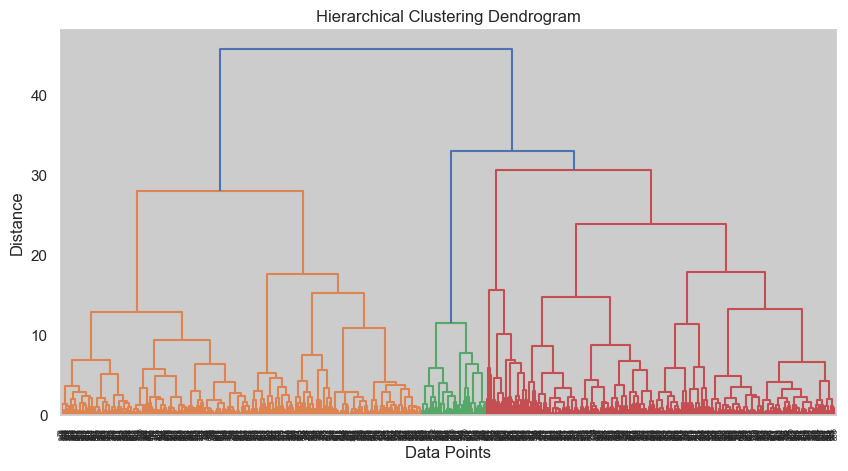

✅ Agglomerative Clustering Done


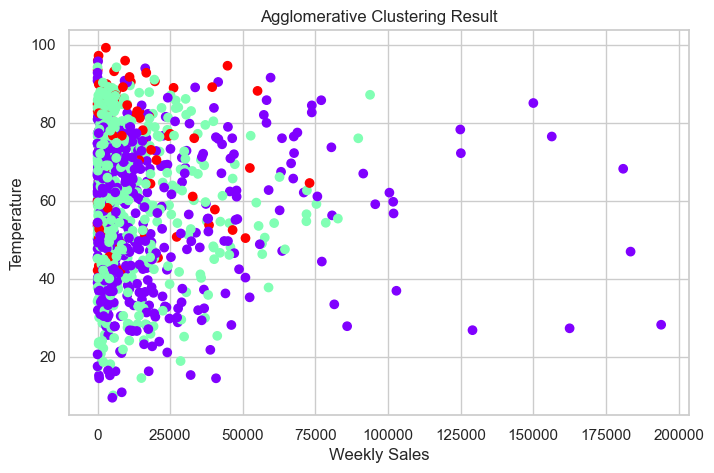


🔥 FINAL CLUSTERS (HIERARCHY RESULT):

Cluster 0:
    Store  Dept  Weekly_Sales  Temperature
1      18    93       3196.12        38.10
5      29    33       3311.26        43.43
6      13    52       6335.65        45.12
7      13    49       8971.23        77.30
9      10    49      17308.45        82.27
11     26    82      17034.57        64.94
14     19    10      23193.57        32.92
15     34    97      16863.99        42.74
18     23    38      40789.48        14.50
20     34    30       1996.00        55.04

Cluster 1:
    Store  Dept  Weekly_Sales  Temperature
10     11    33       5763.39        86.13
12      5    60        252.00        76.65
13     31    36       5927.00        84.71
17      5     5       6469.61        85.81
21     36     1       1451.39        50.87
23      6    28        795.89        58.82
25     37    97      13189.29        81.76
27      2    46      28595.87        68.07
28     32    54         10.00        39.90
29      9    90       3473.70      

In [38]:
# ==============================
# 📦 IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================
# 🎯 SELECT FEATURES
# ==============================
X = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']]

# ==============================
# 📏 SCALING
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 🔗 DENDROGRAM (HIERARCHY VISUAL)
# ==============================
plt.figure(figsize=(10,5))

linked = linkage(X_scaled, method='ward')

dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# ==============================
# 🔵 AGGLOMERATIVE CLUSTERING
# ==============================
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Agglo_Cluster'] = hc.fit_predict(X_scaled)

print("✅ Agglomerative Clustering Done")

# ==============================
# 📊 VISUALIZATION
# ==============================
plt.figure(figsize=(8,5))

plt.scatter(
    df['Weekly_Sales'],
    df['Temperature'],
    c=df['Agglo_Cluster'],
    cmap='rainbow'
)

plt.xlabel("Weekly Sales")
plt.ylabel("Temperature")
plt.title("Agglomerative Clustering Result")
plt.show()

# ==============================
# 🧾 HIERARCHY PRINT (FINAL GROUPS)
# ==============================
print("\n🔥 FINAL CLUSTERS (HIERARCHY RESULT):")

for cluster in sorted(df['Agglo_Cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(df[df['Agglo_Cluster'] == cluster][['Store','Dept','Weekly_Sales','Temperature']].head(10))